# PayWatch: exploratory data analysis

IEEE-CIS Fraud Detection (`train_transaction.csv` joined to `train_identity.csv`). Every number below is computed when the notebook runs on Kaggle. The goal is to justify the modelling choices: metric, split, features and missing-value handling.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
%matplotlib inline
pd.set_option("display.width", 140)
RAW = "/kaggle/input/competitions/ieee-fraud-detection"
tx = pd.read_csv(f"{RAW}/train_transaction.csv")
idn = pd.read_csv(f"{RAW}/train_identity.csv")
df = tx.merge(idn, on="TransactionID", how="left", indicator="has_identity")
df["has_identity"] = (df["has_identity"] == "both").astype(int)
df["day"] = df["TransactionDT"] / 86400
df["hour"] = (df["TransactionDT"] // 3600) % 24
fraud_rate = df.isFraud.mean()
print("rows x columns:", df.shape, "| time span (days):", round(df.day.max() - df.day.min(), 1))
print("fraud rows:", int(df.isFraud.sum()), "| fraud rate:", round(fraud_rate, 4))

rows x columns: (590540, 437) | time span (days): 182.0
fraud rows: 20663 | fraud rate: 0.035


## 1. Class balance: why accuracy is the wrong metric

In [2]:
print(f"A model that always predicts 'not fraud' is {1 - fraud_rate:.1%} accurate and catches 0 fraud.")
print("-> evaluate with PR-AUC and recall at a fixed false-positive rate, not accuracy.")

A model that always predicts 'not fraud' is 96.5% accurate and catches 0 fraud.
-> evaluate with PR-AUC and recall at a fixed false-positive rate, not accuracy.


## 2. Time structure: why the split must be time-ordered

,rows,fraud_rate,mean_amount
day,,,
0,23810,0.0281,129.3605
1,27803,0.0261,127.7085
2,34470,0.0255,131.4175
3,37251,0.0185,120.7029
4,24041,0.0382,133.6153
5,21868,0.0383,135.1947
6,20392,0.0386,135.8337
7,20025,0.0412,134.5271
8,20246,0.0455,141.5119


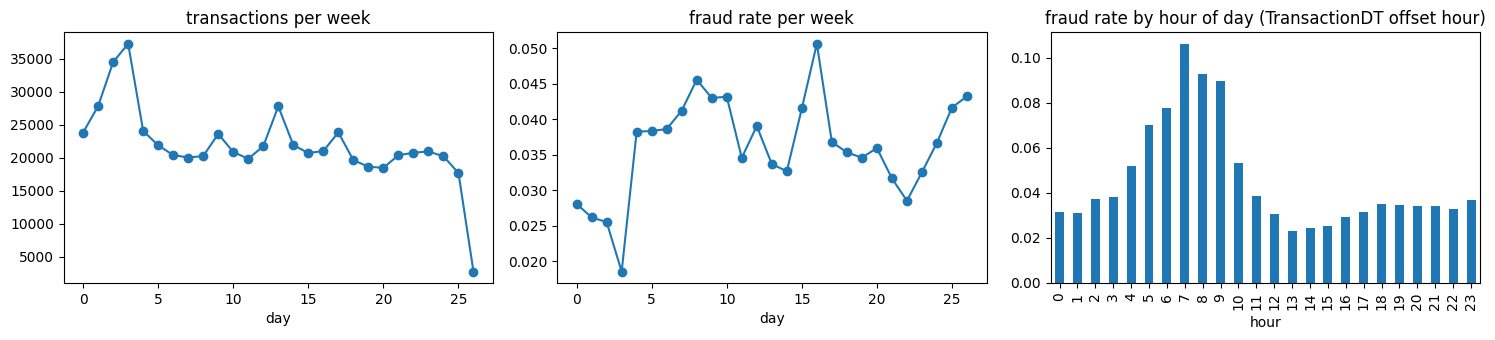

fraud-rate range across weeks: 0.0185 to 0.0506


In [3]:
weekly = df.groupby((df.day // 7).astype(int)).agg(rows=("isFraud", "size"), fraud_rate=("isFraud", "mean"),
                                                 mean_amount=("TransactionAmt", "mean"))
display(weekly.round(4))
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
weekly.rows.plot(ax=ax[0], marker="o", title="transactions per week")
weekly.fraud_rate.plot(ax=ax[1], marker="o", title="fraud rate per week")
hourly = df.groupby("hour").isFraud.mean()
hourly.plot(kind="bar", ax=ax[2], title="fraud rate by hour of day (TransactionDT offset hour)")
plt.tight_layout(); plt.show()
print("fraud-rate range across weeks:", round(weekly.fraud_rate.min(), 4), "to", round(weekly.fraud_rate.max(), 4))

## 3. Amounts

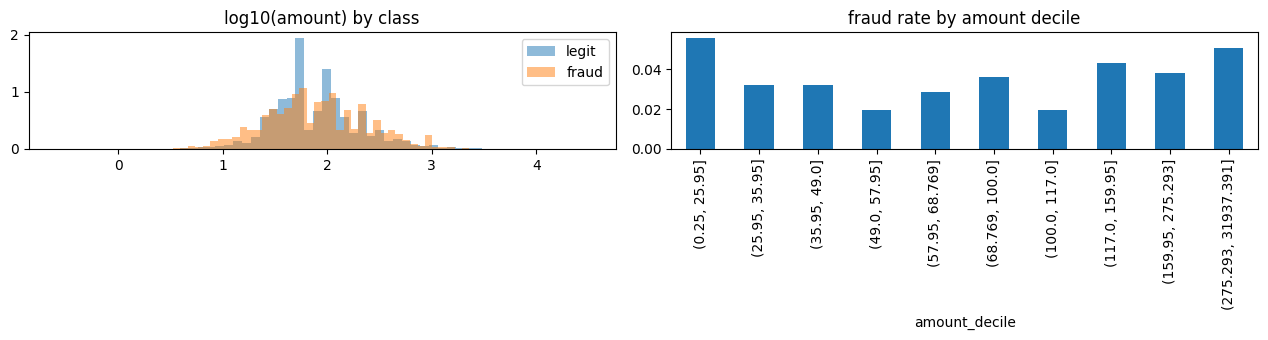

            count    mean     std   min    25%   50%    75%       max
isFraud                                                              
0        569877.0  134.51  239.40  0.25  43.97  68.5  120.0  31937.39
1         20663.0  149.24  232.21  0.29  35.04  75.0  161.0   5191.00


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
for label, g in df.groupby("isFraud"):
    ax[0].hist(np.log10(g.TransactionAmt.clip(lower=0.01)), bins=60, alpha=0.5, density=True, label="fraud" if label else "legit")
ax[0].set_title("log10(amount) by class"); ax[0].legend()
df["amount_decile"] = pd.qcut(df.TransactionAmt, 10, duplicates="drop")
df.groupby("amount_decile").isFraud.mean().plot(kind="bar", ax=ax[1], title="fraud rate by amount decile")
plt.tight_layout(); plt.show()
print(df.groupby("isFraud").TransactionAmt.describe().round(2))

## 4. Risk by category

In [5]:
for col in ["ProductCD", "card4", "card6", "DeviceType", "has_identity"]:
    t = df.groupby(col, dropna=False).isFraud.agg(rows="size", fraud_rate="mean").sort_values("rows", ascending=False)
    print(f"\n{col}"); print(t.head(8).round(4).to_string())
top = df.P_emaildomain.value_counts().head(12).index
print("\nP_emaildomain (12 largest)")
print(df[df.P_emaildomain.isin(top)].groupby("P_emaildomain").isFraud.agg(rows="size", fraud_rate="mean")
      .sort_values("fraud_rate", ascending=False).round(4).to_string())
identity_cov = df.has_identity.mean()
print("\nshare of transactions with identity information:", round(identity_cov, 3))


ProductCD
             rows  fraud_rate
ProductCD                    
W          439670      0.0204
C           68519      0.1169
R           37699      0.0378
H           33024      0.0477
S           11628      0.0590

card4
                    rows  fraud_rate
card4                               
visa              384767      0.0348
mastercard        189217      0.0343
american express    8328      0.0287
discover            6651      0.0773
NaN                 1577      0.0260

card6
                   rows  fraud_rate
card6                              
debit            439938      0.0243
credit           148986      0.0668
NaN                1571      0.0248
debit or credit      30      0.0000
charge card          15      0.0000



DeviceType
              rows  fraud_rate
DeviceType                    
NaN         449730      0.0210
desktop      85165      0.0652
mobile       55645      0.1017

has_identity
                rows  fraud_rate
has_identity                    
0             446307      0.0209
1             144233      0.0785

P_emaildomain (12 largest)


                 rows  fraud_rate
P_emaildomain                    
outlook.com      5096      0.0946
hotmail.com     45250      0.0530
gmail.com      228355      0.0435
icloud.com       6267      0.0314
comcast.net      7888      0.0312
live.com         3041      0.0276
anonymous.com   36998      0.0232
yahoo.com      100934      0.0228
msn.com          4092      0.0220
aol.com         28289      0.0218
att.net          4033      0.0074
sbcglobal.net    2970      0.0040

share of transactions with identity information: 0.244


## 5. Missing values

columns: 438 | >90% missing: 12 | >50% missing: 214


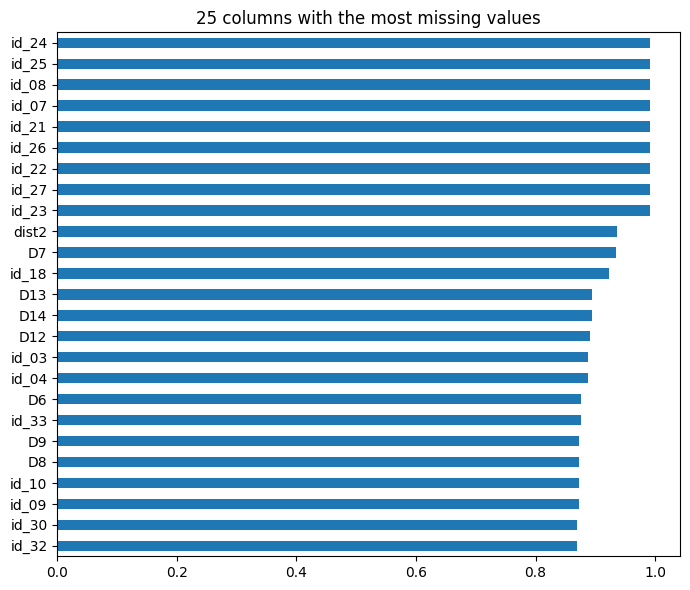

fraud rate when D1 is missing / present: 0.0362 / 0.035
-> missingness itself carries signal, so missing values are filled with a sentinel instead of dropped.


In [6]:
miss = df.isna().mean().sort_values(ascending=False)
print("columns:", df.shape[1], "| >90% missing:", int((miss > 0.9).sum()), "| >50% missing:", int((miss > 0.5).sum()))
miss.head(25).plot(kind="barh", figsize=(7, 6), title="25 columns with the most missing values")
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()
d1 = df.D1.isna()
print("fraud rate when D1 is missing / present:", round(df[d1].isFraud.mean(), 4), "/", round(df[~d1].isFraud.mean(), 4))
print("-> missingness itself carries signal, so missing values are filled with a sentinel instead of dropped.")

## 6. Entity structure: why lagged fraud history can help

No real user id exists, so a card composite (`card1`, `card2`, `card3`, `card5`) stands in for the user.

In [7]:
d = df.sort_values("TransactionDT")[["TransactionDT", "isFraud", "card1", "card2", "card3", "card5"]].copy()
d["card_key"] = d[["card1", "card2", "card3", "card5"]].astype(str).agg("_".join, axis=1)
d["n_before"] = d.groupby("card_key").cumcount()
fraud = d[d.isFraud == 1].copy()
known_card_share = (fraud.n_before > 0).mean()
fraud["first_fraud_t"] = fraud.groupby("card_key").TransactionDT.transform("min")
repeat7_share = ((fraud.TransactionDT - fraud.first_fraud_t) >= 7 * 86400).mean()
print("distinct card composites:", d.card_key.nunique())
print("share of fraud on a card that had an earlier transaction:", round(known_card_share, 3))
print("share of fraud on a card whose FIRST fraud was at least 7 days earlier:", round(repeat7_share, 3))

distinct card composites: 14845
share of fraud on a card that had an earlier transaction: 0.982
share of fraud on a card whose FIRST fraud was at least 7 days earlier: 0.809


## 7. What this means for the model

In [8]:
print(f"1. Fraud is rare ({fraud_rate:.1%}): use PR-AUC / recall at fixed FPR and class weights, never accuracy.")
print(f"2. Fraud rate moves from {weekly.fraud_rate.min():.1%} to {weekly.fraud_rate.max():.1%} week to week: split by time, not at random.")
print(f"3. {known_card_share:.0%} of fraud is on a card seen before and {repeat7_share:.0%} follows an earlier fraud on the same card "
      "by 7+ days: lagged entity fraud history is worth building.")
print(f"4. Only {identity_cov:.0%} of rows have identity data and many columns are mostly missing: keep missingness as a signal.")
print("5. A reconstructed user id is a proxy (no real UPI ids): say so wherever the features are quoted.")

1. Fraud is rare (3.5%): use PR-AUC / recall at fixed FPR and class weights, never accuracy.
2. Fraud rate moves from 1.9% to 5.1% week to week: split by time, not at random.
3. 98% of fraud is on a card seen before and 81% follows an earlier fraud on the same card by 7+ days: lagged entity fraud history is worth building.
4. Only 24% of rows have identity data and many columns are mostly missing: keep missingness as a signal.
5. A reconstructed user id is a proxy (no real UPI ids): say so wherever the features are quoted.
